In [1]:
import os
os.chdir("/home/philbou/projects/def-rfajber/philbou/FAWA")
import diagnostic_plot_helper as dps
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import FAWA_mod as fw
import cartopy.crs as ccrs
from skimage import measure
import matplotlib.colors as mcolors

In [19]:
def select_region3D(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1]),
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region

ds_ = xr.open_mfdataset("/home/philbou/scratch/isca_data/RT42_sst_0_bucket/run0175/atmos_monthly.nc")
lat_bounds = (0, 90)
lon_bounds = (0,360)#(-175 + 360, -30 + 360)
depth_bounds = (0, 1000)
ds  = select_region3D(ds_, lat_bounds, lon_bounds, depth_bounds)
lat = ds.lat.values
lat_interp = np.linspace(lat[0],lat[-1],100)
lon = ds.lon.values
latb = ds.latb.values

lonb = ds.lonb.values
# monotonically decreasing values of W
W_ = dps.vertical_int(ds.sphum.interp(lat =lat_interp).values,100*ds.phalf.values,ds.ps.mean(dim= "time").interp(lat =lat_interp).values)
W_real = np.mean(W_,axis = 0)[np.newaxis,:,:]
max_W = np.max(W_real)
min_W = np.min(W_real)

W_zonal = np.linspace(max_W,min_W,len(lat_interp))
W_2D_rest = np.zeros((len(lat_interp),len(lon)))
A = np.zeros_like(W_2D_rest)
W = W_2D_rest[np.newaxis,:,:].copy()
for i in range(len(lat_interp)):
    W_2D_rest[i,:] = W_zonal[i] * np.ones_like(lon)
    W[0,i,:] = W_zonal[i] * np.ones_like(lon) 
    
amplitude = 40       # maximum vertical extent of sine (in array indices)
period = 360          # number of columns per sine wave
offset = 0#len(lat_interp) // 2     # shift sine vertically into array

# sine curve as row indices
y_sine = amplitude * np.sin(2 * np.pi * lon / period)**2 + offset
y = np.arange(len(lat_interp)).reshape(-1, 1)  # column vector for broadcasting
# Mask: True for points with row index <= sine curve
mask = y <= y_sine
W[mask[np.newaxis,:,:]] = W_zonal[offset] 

W[0,60:70,50:80] = W_zonal[offset] 
lon_rad = np.deg2rad(lon)
lat_interp_rad = np.deg2rad(lat_interp)
dlon_tmp = (lon_rad[1] - lon_rad[0])
dlat_tmp = lat_interp_rad[1] - lat_interp_rad[0]
A = fw.compute_A_timestep(0,W,W_zonal,lon,lat_interp,dlon_tmp,dlat_tmp)


/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


In [20]:
print(W.shape,W_real.shape)

(1, 100, 128) (1, 100, 128)


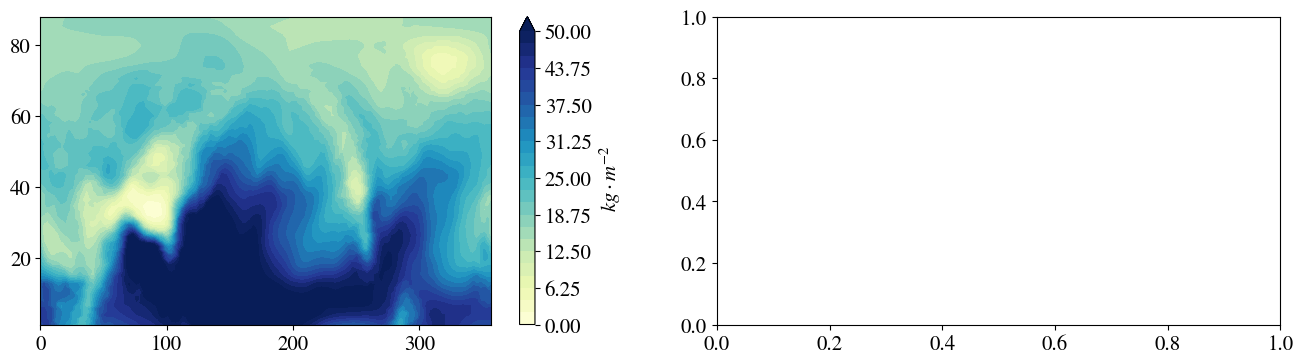

In [21]:
fig,axs = plt.subplots(1,2,figsize =(16,4))
cb = axs[0].contourf(lon,lat_interp,W_real[0,:,:],cmap = "YlGnBu",levels = np.linspace(0,50,25),extend = "max")
cbar = plt.colorbar(cb)
cbar.set_label("$kg \\cdot m^{-2}$")

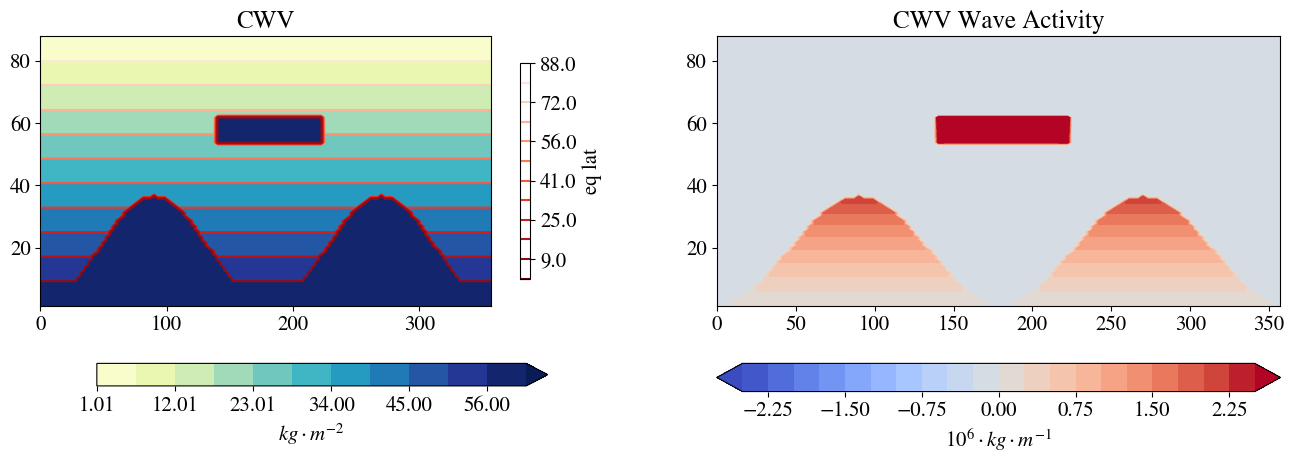

In [22]:
fig,axs = plt.subplots(1,2,figsize =(16,5))
cb = axs[0].contourf(lon,lat_interp,W[0,:,:],cmap = "YlGnBu",levels = W_zonal[::-9],extend = "max")
cbar = plt.colorbar(cb,shrink=0.8,orientation='horizontal')
cbar.set_label("$kg \\cdot m^{-2}$")
axs[0].set_title("CWV")

cb = axs[0].contour(lon,lat_interp,W[0,:,:],cmap = "Reds",levels = W_zonal[::-9])
cbar = plt.colorbar(cb,shrink=0.8)
cbar.set_ticklabels(np.round(lat_interp[::-9],0))
cbar.ax.invert_yaxis()
cbar.set_label("eq lat")
cb = axs[1].contourf(lon,lat_interp,1e-6 * A,cmap = "coolwarm",levels = np.linspace(-2.5,2.5,21),extend = "both")
cbar = plt.colorbar(cb,orientation = "horizontal")
cbar.set_label("$10^{6} \\cdot kg \\cdot m^{-1}$")
axs[1].set_title("CWV Wave Activity")
"""cb = axs[1].contour(lon,lat_interp,W_real[0,:,:],cmap = "Reds",levels = W_zonal[::-9])
cbar = plt.colorbar(cb,shrink=0.8)
cbar.set_ticklabels(np.round(lat_interp[::-9],0))
cbar.ax.invert_yaxis()"""

plt.savefig("test_4.png",dpi = 250)